In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ashishjangra27_doodle_dataset_path = kagglehub.dataset_download('ashishjangra27/doodle-dataset')

print('Data source import complete.')


e:\TSE\FISE3\SPE_INFO_Big_Data_management_and_analysis\Projet Big Data\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source import complete.


# Doodles Dataset with Convolutional Neural Network (CNN)


![Doodle Classifier](https://storage.googleapis.com/gweb-cloudblog-publish/images/quick-draw-1u639.max-900x900.PNG)


# Overview

This notebook explores the Doodles dataset, and building a Convolutional Neural Network model to detect the type of drawing. **Note** in this example I shortened the original dataset to only include a certain subset
of the provided doodles for runtime purposes, however, it should also work with minimal changes to the code and a lot of patience to go along with it.
:)

#### *Data Preparation*
Filter and preprocess the dataset to prepare it for model training.

Filter Data: Extract rows where the word column matches one of the desired categories ('cat', 'dog', 'bird').
Load and Preprocess Images: Convert image file paths to NumPy arrays, resize images to a fixed size, and normalize pixel values.

#### *CNN Architecture*
Define and build the CNN model for image classification.

Define Layers: Add convolutional layers, pooling layers, and fully connected layers to the model.

#### *Model Training and Fitting*

#### *Model Evaluation with Example Case*

*Dataset via ASHISH JANGRA on Kaggle*
***Jorge Nunez** 08/06/2024*

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

torch.cuda.is_available()
device = torch.device("cuda")
print(f'Using device: {device}')

Using device: cuda


In [13]:
# Chemin local du dataset
dataset_path = r'c:\Users\ainar\.cache\kagglehub\datasets\ashishjangra27\doodle-dataset\versions\1'
doodle_folder = dataset_path + r'\doodle'
print(f"Dataset téléchargé dans : {dataset_path}")
print(f"Dossier doodle : {doodle_folder}")

Dataset téléchargé dans : c:\Users\ainar\.cache\kagglehub\datasets\ashishjangra27\doodle-dataset\versions\1
Dossier doodle : c:\Users\ainar\.cache\kagglehub\datasets\ashishjangra27\doodle-dataset\versions\1\doodle


#### 1.1 Loading the CSV

In [14]:
# Charger le CSV depuis le chemin local
csv_path = r'c:\Users\ainar\.cache\kagglehub\datasets\ashishjangra27\doodle-dataset\versions\1\master_doodle_dataframe.csv'   
df = pd.read_csv(csv_path)
#df = df.sample(n=1000, random_state=42)  # Sample the dataset
# List of words you want to keep
words_to_keep = ['apple', 'cat', 'dog', 'bird', 'hammer','bicycle','car','house','tree']

# Filter the DataFrame
filtered_df = df[df['word'].isin(words_to_keep)]

# Verify the filtering
print(filtered_df['word'].value_counts())  # Check the distribution of classes
df = filtered_df

print(df.shape)
df.head()

word
car        3000
dog        3000
bicycle    3000
hammer     3000
house      3000
cat        3000
tree       3000
apple      3000
bird       3000
Name: count, dtype: int64
(27000, 6)


,countrycode,drawing,key_id,recognized,word,image_path
114000,CA,"[[[71, 68, 74, 89, 92, 90, 82, 70], [85, 101, ...",4589738193321984,True,car,data/car/4589738193321984.png
114001,US,"[[[39, 56, 77, 103, 134, 147, 158, 172, 209, 2...",6541107070500864,True,car,data/car/6541107070500864.png
114002,US,"[[[234, 199, 188, 169, 139, 92, 68, 34, 13, 2,...",6419934080925696,True,car,data/car/6419934080925696.png
114003,RU,"[[[69, 51, 6, 0, 14, 32, 44, 61, 77, 94, 99, 1...",6477131922014208,True,car,data/car/6477131922014208.png
114004,US,"[[[14, 10, 10, 16, 30, 62, 181, 177, 177, 205,...",5265405532700672,True,car,data/car/5265405532700672.png


#### 1.2 Preprocessing

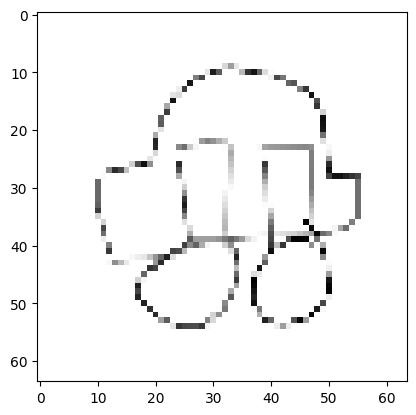

In [15]:
# Remove the 'data/' prefix from the image_path column
df['image_path'] = df['image_path'].str.replace('data/', '', regex=False)

# Verify the change
#print(df['image_path'].head())

# Load image from the 'image_path' column - utilisant le chemin local
def load_images(image_paths, base_path=r'c:\Users\ainar\.cache\kagglehub\datasets\ashishjangra27\doodle-dataset\versions\1\doodle\\', target_size=(64, 64)):
    images = []
    for file_path in image_paths:
        full_path = base_path + file_path
        img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
        if img is not None:
            img = cv2.resize(img, target_size)  # Resize the image to 64x64 pixels
            img = img / 255.0  # Normalize pixel values to [0, 1]
        else:
            img = np.zeros(target_size)  # If the image cannot be loaded, return a blank image
        images.append(img)
    return np.array(images)

# Apply the function to the entire 'image_path' column
image_array = load_images(df['image_path'].values)

# Display an example image using plt.imshow
plt.imshow(image_array[10], cmap='gray')
plt.show()

In [16]:
# Encode categorical 'word' column into a numerical column
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['word'])

In [17]:
X = np.stack(image_array)  # Stack all image arrays into a single numpy array

y = df['label'].values  # Labels
X.dtype

dtype('float64')

In [27]:
# Split the dataset into training(75%) and validation sets(15%) and test sets(15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 x 0.85 ≈ 0.15
print(f'Train set size: {X_train.shape[0]}')
print(f'Validation set size: {X_val.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

Train set size: 18899
Validation set size: 4051
Test set size: 4050


In [31]:
# PyTorch n'a pas besoin de one-hot encoding pour CrossEntropyLoss
# Les labels restent sous forme d'entiers
num_classes = len(words_to_keep)

# Convertir les données en tenseurs PyTorch
X_train = torch.FloatTensor(X_train).unsqueeze(1)  # Ajouter une dimension de canal (1 pour grayscale)
X_val = torch.FloatTensor(X_val).unsqueeze(1)
X_test = torch.FloatTensor(X_test).unsqueeze(1)
y_train = torch.LongTensor(y_train)  # Les labels doivent être LongTensor
y_val = torch.LongTensor(y_val)
y_test = torch.LongTensor(y_test)

In [28]:
# Définir le modèle CNN avec PyTorch
class DoodleCNN(nn.Module):
    def __init__(self, num_classes):
        super(DoodleCNN, self).__init__()
        
        # First Convolutional Layer
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=0)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Second Convolutional Layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=0)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Third Convolutional Layer
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=0)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 6 * 6, 64)  # Calculé en fonction de la taille après convolutions
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

# Créer une instance du modèle
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DoodleCNN(num_classes).to(device)

# Afficher le résumé du modèle
print(model)
print(f"\nUtilisation du device: {device}")

DoodleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2304, out_features=64, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=64, out_features=9, bias=True)
)

Utilisation du device: cpu


In [29]:
# Définir l'optimizer et la fonction de perte
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [32]:
# Créer des DataLoaders pour l'entraînement et la validation
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Entraîner le modèle
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    # Phase d'entraînement
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass et optimisation
        loss.backward()
        optimizer.step()
        
        # Statistiques
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    # Phase de validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    # Calculer les moyennes
    train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    
    # Stocker l'historique
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

Epoch [1/10], Train Loss: 1.1554, Train Acc: 0.5760, Val Loss: 0.5354, Val Acc: 0.8203
Epoch [2/10], Train Loss: 0.4696, Train Acc: 0.8419, Val Loss: 0.4178, Val Acc: 0.8578
Epoch [3/10], Train Loss: 0.3769, Train Acc: 0.8744, Val Loss: 0.3830, Val Acc: 0.8660
Epoch [4/10], Train Loss: 0.3200, Train Acc: 0.8931, Val Loss: 0.3446, Val Acc: 0.8815
Epoch [5/10], Train Loss: 0.2766, Train Acc: 0.9074, Val Loss: 0.3328, Val Acc: 0.8869
Epoch [6/10], Train Loss: 0.2467, Train Acc: 0.9185, Val Loss: 0.3296, Val Acc: 0.8909
Epoch [7/10], Train Loss: 0.2219, Train Acc: 0.9238, Val Loss: 0.3304, Val Acc: 0.8916
Epoch [8/10], Train Loss: 0.1982, Train Acc: 0.9329, Val Loss: 0.3270, Val Acc: 0.8936
Epoch [9/10], Train Loss: 0.1820, Train Acc: 0.9380, Val Loss: 0.3178, Val Acc: 0.8948
Epoch [10/10], Train Loss: 0.1591, Train Acc: 0.9452, Val Loss: 0.3451, Val Acc: 0.8921


In [33]:
# Évaluer le modèle sur l'ensemble de test
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = test_correct / test_total
print(f'Test accuracy: {test_acc:.4f}')

Test accuracy: 0.8916


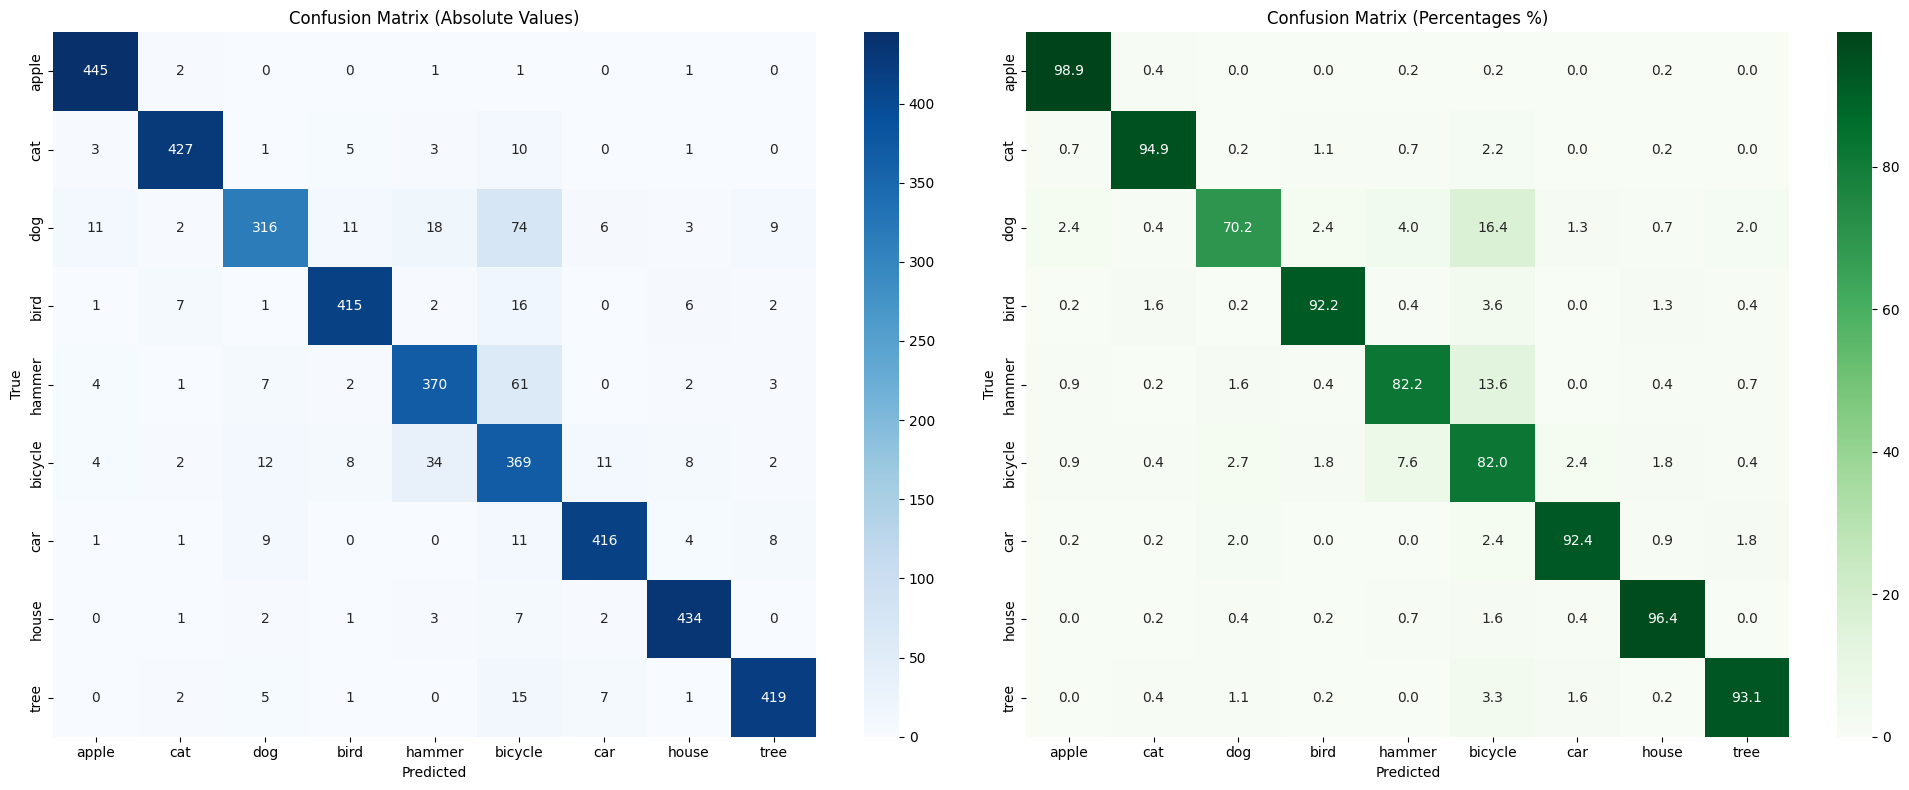

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Faire des prédictions sur l'ensemble de test
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Créer la matrice de confusion
cm = confusion_matrix(all_labels, all_predictions)

# Calculer les pourcentages par ligne (normalisation par classe réelle)
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Créer une figure avec deux subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matrice de confusion avec valeurs absolues
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=words_to_keep, 
            yticklabels=words_to_keep,
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Absolute Values)')

# Matrice de confusion avec pourcentages
sns.heatmap(cm_percentage, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=words_to_keep, 
            yticklabels=words_to_keep,
            ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Percentages %)')

plt.tight_layout()
plt.show()

In [13]:
# Sauvegarder le modèle PyTorch
torch.save(model.state_dict(), 'doodle_classifier_model.pth')
print('Modèle sauvegardé: doodle_classifier_model.pth')

Modèle sauvegardé: doodle_classifier_model.pth


True Label: tree, Predicted Label: tree


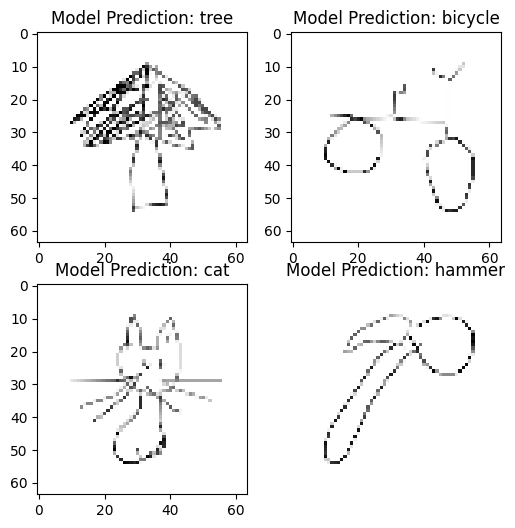

In [15]:
# Faire des prédictions sur l'ensemble de test
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        predictions.extend(predicted.cpu().numpy())
        true_labels.extend(labels.numpy())

# Convertir en arrays numpy
predictions = np.array(predictions)
true_labels = np.array(true_labels)

# Convertir les prédictions en mots
predicted_words = encoder.inverse_transform(predictions)
true_words = encoder.inverse_transform(true_labels)

# Sélectionner des indices à afficher
index = [1, 2, 3, 4]

# Convertir X_test en numpy si nécessaire
X_test_np = X_test.cpu().numpy()

plt.figure(figsize=(6, 6))
plt.subplot(2, 2, 1)
plt.imshow(X_test_np[index[0]].reshape(64, 64), cmap='gray')
plt.title(f"Model Prediction: {predicted_words[index[0]]}")
print(f"True Label: {true_words[index[0]]}, Predicted Label: {predicted_words[index[0]]}")

plt.subplot(2, 2, 2)
plt.imshow(X_test_np[index[1]].reshape(64, 64), cmap='gray')
plt.title(f"Model Prediction: {predicted_words[index[1]]}")

plt.subplot(2, 2, 3)
plt.imshow(X_test_np[index[2]].reshape(64, 64), cmap='gray')
plt.title(f"Model Prediction: {predicted_words[index[2]]}")

plt.subplot(2, 2, 4)
plt.imshow(X_test_np[index[3]].reshape(64, 64), cmap='gray')
plt.title(f"Model Prediction: {predicted_words[index[3]]}")

plt.axis('off')
plt.show()